## 1 - Likelihood

### 1.1 - Probability Distributions
A probability distribution describes how the values of a random variable are distributed. It assigns probabilities to possible outcomes for discrete variables or probability densities for continuous variables.

### 1.2 - Probability Density Functions
For a continuous random variable, probabilities are described by a probability density function (pdf) $f(x)$, where the probability of $X$ falling within an interval $[a, b]$ is:

$$
P(a \leq X \leq b) = \int_a^b f(x) \, dx
$$

The pdf must satisfy:

- $f(x) \geq 0$ for all $x$.
- The integral over all possible values equals 1:

$$
\int_{-\infty}^{\infty} f(x) \, dx = 1
$$

This means that the probability of the variable taking on a value on the real line is 1.  Similarly, the sum over all possible outcomes for a discrete variable should also be 1.  As we sum over all possible outcomes, the probability that one of these occurs must be 1 of course.  E.g., think about a 50/50 coinflip: the probability that it is either head or tail must be 1!

**Normal (or Gaussian) Distribution**

The normal distribution is a common continuous distribution characterized by a mean $\mu$ and variance $\sigma^2$. The pdf of such a Gaussian is given as:

$$
f(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} \times e^{\left( - \frac{(x - \mu)^2}{2 \sigma^2} \right)}
$$

Below we visualize several Gaussian Distributions (Normal Distributions) with an average of 0 and standard deviations between 1 and 5. We create 5000 datapoints for each.

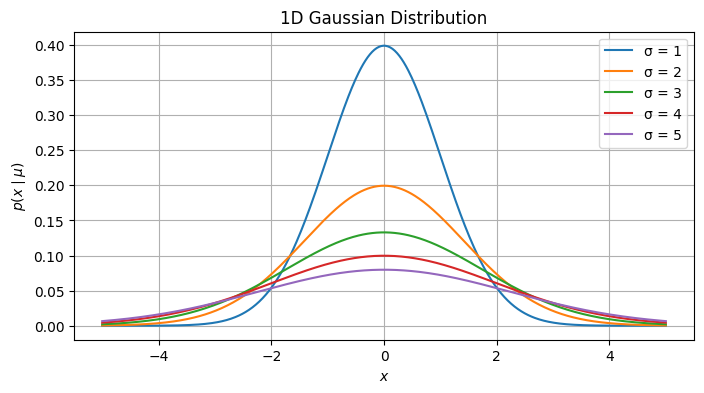

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mean and standard deviation
mu = 0     # You can change this to any value
sigmas = [1,2,3,4,5]   # Given in the problem

plt.figure(figsize=(8, 4))

for sigma in sigmas:
    # x-axis values
    x = np.linspace(-5, 5, 500)

    # Gaussian function
    p_x = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu)**2/(2*sigma)))

    # Plot
    plt.plot(x, p_x, label=f'σ = {sigma}')

plt.title('1D Gaussian Distribution')
plt.xlabel('$x$')
plt.ylabel('$p(x \mid \mu)$')
plt.grid(True)
plt.legend()
plt.show()


So, what can we do with these five Gaussians with an average ($\mu$) of 0, and standard deviations ($\sigma$) ranging from 1 to 5.  As a start, say that we are interested in the probability that our next observation will be somewhere in the range $[1,-1]$. Given that this observation comes from the density specified, then we can use the PDF to compute this.

As stated above:

$$
P(a \leq X \leq b) = \int_a^b f(x) \, dx
$$

For our Gaussian, we plug in the pdf we defined above to get:

$$
P(a \leq X \leq b) = \int_a^b \frac{1}{\sqrt{2 \pi \sigma^2}} \times e^{\left( - \frac{(x - \mu)^2}{2 \sigma^2} \right)} \, dx
$$

In the cell below we compute the likely hood of $P(-1 \leq X \leq 1)$ for all 5 values of sigma, using the cdf from scikit.

In [ ]:
import numpy as np
import scipy.stats as stats

mu = 0
sigmas = [1, 2, 3, 4, 5]

for sigma in sigmas:
    # Use the CDF to find P(-1 <= X <= 1)
    prob = stats.norm.cdf(1, loc=mu, scale=sigma) - stats.norm.cdf(-1, loc=mu, scale=sigma)
    print(f'Probability that X is between -1 and 1 for σ={sigma}: {prob:.4f}')


Probability that X is between -1 and 1 for σ=1: 0.6827
Probability that X is between -1 and 1 for σ=2: 0.3829
Probability that X is between -1 and 1 for σ=3: 0.2611
Probability that X is between -1 and 1 for σ=4: 0.1974
Probability that X is between -1 and 1 for σ=5: 0.1585


Does it make sense that this probability decreases with increasing $\sigma$?

### 1.3 - Likelihood function
A likelihood function (often simply called the likelihood) measures how well a statistical model explains observed data by calculating the probability of seeing that data under different parameter values of the model.

Consider a probability density function $f(x \mid \theta)$, where $ x $ is a realization of the random variable $ X $ and $\theta$ is some generic collection of parameters for the PDF under consideration.

In this setting, the likelihood function, often denoted $ \mathcal{L} $ or simply $L$, equals

$$
\mathcal{L}(\theta \mid x) = f(x \mid \theta).
$$

The main difference with 1.2. is that there we assume $\theta$ (or specifically $\mu$ and $\sigma$) given or known, so we can calculate the probability density for observations $X = x$ using the PDF $f(x \mid \theta)$.  Conversely, when we are using our observations, assumed to be given, to measure the quality of our parameters, ${\textstyle f(x\mid \theta )}$ is a likelihood function, i.e., it is not considered a function of $x$ but of $\theta$!

Typically, we want to measure the likelihood of $\theta$ based on more than one data point.  Assuming that we have $n$ indepedent draws, i.e., $n$ indepedent observation, $x_1,\dots,x_n$, the PDF these datapoints is just the product of their separate PDFs:
$$L(\theta|\mathbf{x})=\prod _{i=1}^{n}f(x_i|\theta),$$
where $\mathbf{x}$ contains all $n$ observations $x_1$ to $x_n$.

(What does the $\prod$ symbol mean?  You may want to compare this to the $\sum$ symbol!)

### 1.3 - Log-likelihood function
Often, we rather consider the log-likelihood, i.e., the logrithm of the likelihood, which converts the product into a sum.  This transformation can improve the numerical stability when performing computations with these functions.  Also, it can simplify expressions and may, generally, be easier to work with.

Consider, for example, the log-likelihood for $n$ independent observations from a normal distribution with mean $\mu$ and standard devition $\sigma$.  In that case, the log-likelihood becomes
$$
\begin{align*}\log L(\mu ,\sigma ^{2}|\mathbf{x})&=\log \left(\prod _{i=1}^{n}\frac{1}{\sqrt{2\pi \sigma ^{2}}}\exp \left(-\frac{(x_{i}-\mu )^{2}}{2\sigma ^{2}}\right)\right)\\
&=-\frac{n}{2}\log (2\pi \sigma ^{2})-\frac{1}{2\sigma ^{2}}\sum _{i=1}^{n}(x_{i}-\mu )^{2}.\end{align*}$$

##### Question
Explain how this rewriting works, using the logorithm rewriting rules!

YOUR ANSWER HERE

### 1.5 - Maximimum Likelihood Estimation
If we want to find the distribution that best describes our data, we want to find the distribution with the highest likelihood estimation. Since a higher value for the Likelihood Estimation funciton means that it is more likely that this data would be produced by this underlying distribution.

If we stick to our example of the Gaussian/Normal distribution (aka we assume that the underlying distribution is certainly a Gaussian), this means we want to find the values for $(\mu, \sigma^2)$ that result in the highest likelihood estimation. Hence why we call it the Maximum Likelihood Estimation.

- For simple models, with a few attributes, you can do this analytically by taking derivatives, setting them to zero, and solving for $\theta$.

- For more complex models, this is done computationally using algorithms like gradient descent, which iteratively adjust the parameters to increase the likelihood until a maximum is found. This will be discussed later in this course, or future courses!

## 2 - likelyhood for actual data
Let us now delve into the data from last week. Specifically we will look at the distribution of "sepal_width". Below we plot a histogram, which simply counts the number of elements in the dataset between several intervals, in this case 20 intervals. For example, we see that around 27 irises have a sepal_width of about 3.

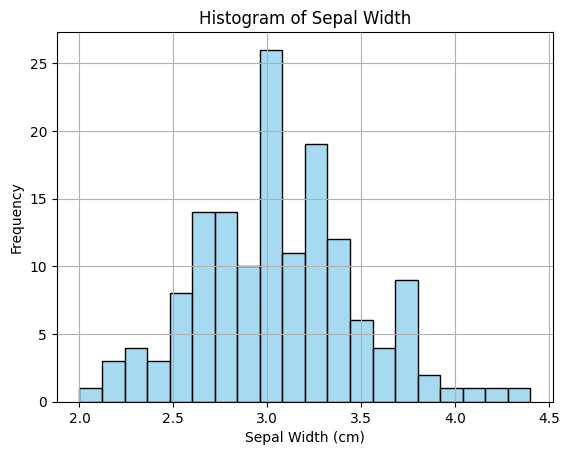

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris_data = sns.load_dataset('iris')

# Plot histogram of petal width
sns.histplot(data=iris_data, x='sepal_width', bins=20, color='skyblue')
plt.title('Histogram of Sepal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

What are the odds of the sepal width being between 2.5 and 3.5 for our dataset? This is not a trivial question, and even if you find the answer, what about future data from the same source? Will your answer still be correct, or would you have to recalculate?

We want to find a model that describes the probability of each sepal_width, and we want this model to work not only for current data, but also for it to be robust to slight changes within the data. Finding a probablity density funcition that describes the distribution we see above will help us do this, as long as our data behaves somewhat like that probablity density function.

If you look closely at the graph above, you might see that it is quite similar to the Gaussian we showed in 1.1, so maybe we can try to see if we can find the right parameters, such that we can describe this data using a Gaussian PDF.

To start simple, let us take $\mu = 0$ and $\sigma = 1$.

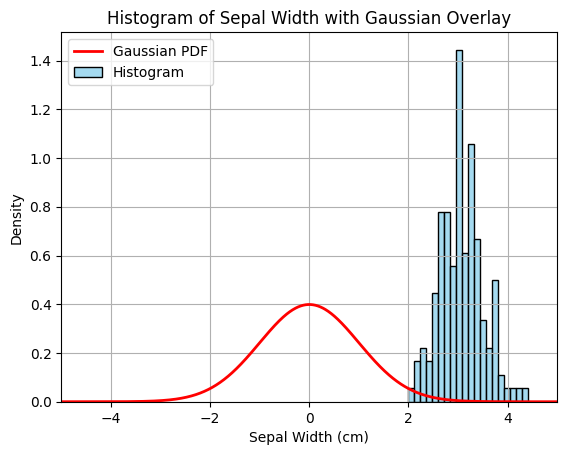

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
iris_data = sns.load_dataset('iris')
data = iris_data['sepal_width']

mu = 0
sigma = 1

# Plot histogram with KDE off
sns.histplot(data, bins=20, stat='density', color='skyblue', edgecolor='black', label='Histogram')

# Generate x values for Gaussian
x = np.linspace(-5, 5, 1000)  # ensure full x range from -5 to 5
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Plot Gaussian
plt.plot(x, gaussian, color='red', lw=2, label='Gaussian PDF')

# Customize plot
plt.title('Histogram of Sepal Width with Gaussian Overlay')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.xlim(-5, 5)  # Set x-axis limits
plt.show()

This does not quite look correct... The curve of the Gaussian is nowhere close to describing our histogram of data. Let us calculate the likelihood function to see how well this model scores:

In [ ]:
from scipy.stats import norm
import numpy as np
import seaborn as sns

# Load the dataset
iris_data = sns.load_dataset('iris')
data = iris_data['sepal_width'].values  # Convert to NumPy array for vectorized operations

# Parameters of the Gaussian model
mu = 0
sigma = 1

n = len(data)

# Compute log-likelihood
log_likelihood = -0.5 * n * np.log(2 * np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)

print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -853.0407799807009


The resulting number is quite low, but by itself for now, also quite meaningless. What does -853 mean, is that really bad, or quite okay? To make sense of this number, we should compare the log-likelihood of this model with the log-likelihood of another. Maybe we can take the $\mu$ and $\sigma$ of our observed datapoints, and use that to fit the model?

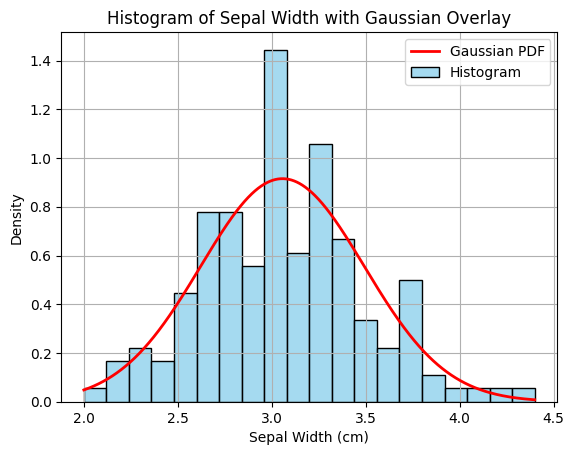

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
iris_data = sns.load_dataset('iris')
data = iris_data['sepal_width']

# Compute mean and std
mu = data.mean()
sigma = data.std()

# Plot histogram with KDE off
sns.histplot(data, bins=20, stat='density', color='skyblue', edgecolor='black', label='Histogram')

# Generate x values for Gaussian
x = np.linspace(data.min(), data.max(), 1000)
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Plot Gaussian
plt.plot(x, gaussian, color='red', lw=2, label='Gaussian PDF')

# Customize plot
plt.title('Histogram of Sepal Width with Gaussian Overlay')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


Visually, this looks a lot better than before! Time to find out what our log-likelihood says!

In [ ]:
from scipy.stats import norm
import numpy as np
import seaborn as sns

# Load the dataset
iris_data = sns.load_dataset('iris')
data = iris_data['sepal_width'].values  # Convert to NumPy array for vectorized operations

# Parameters of the Gaussian model
mu = data.mean()
sigma = data.std()

n = len(data)

# Compute log-likelihood
log_likelihood = -0.5 * n * np.log(2 * np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)

print(f"Log-Likelihood: {log_likelihood}")

Log-Likelihood: -87.77614058001326


Now that we can compare these two values, we can clearly reason that the second model must be a lot better, as it is significantly closer to 0 (a perfect score) than the first.

## 3 - Probabilistic Classification
Given some dataset, let $y$ be the class label. We can assign this label to an object based on its attribute vector $x$. Say that $y$ can take on two classes, which we refer to as class A and B. Now say that given some observed attribute $x$ we want to predict the corresponding class label $y$. To minimize our classification error, we want to assign an object, for which the observed attribute is $x$, to the most probable class.

That is, if $P(y=A|x) > P(y=B|x)$ then we take $y=A$ and the other way around: if $P(y=A|x) < P(y=B|x)$ then we take $y=B$. (In case of equality we can assign it to any of the two classes).

### Visual example
If $x\in\mathbb{R}$ is a one-dimensional attribute, we can visualize/plot/draw $P(y=A)P(x|y=A)$ and $P(y=B)P(x|y=B)$ as functions of $x$ and see when the one is higher or lower than the other.  In other words, we can graphically check which $x$ should be assigned to which class. Let us look back to the iris dataset we used last week, and look into one attribute more deeply!

#### Inspecting the data
Let us load the data using seaborn, like we did in week 1, and take the first column as the attribute we want to inspect further.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 1. Load the Iris dataset using Seaborn
iris_df = sns.load_dataset('iris')

# Get the name of the selected attribute
attribute_name = iris_df.columns[0]
attribute_name

'sepal_length'

Now, let us see what the distribution of values is for each of our classes. To do this, let us first split the dataset on the class attribute, and inspect the values of sepal_length for the resulting dictionary.

In [ ]:
class_data = {}
for name in iris_df['species'].unique():
    # Filter the DataFrame for each species
    data = iris_df[iris_df['species'] == name][attribute_name]
    class_data[name] = data.values

class_data

{'setosa': array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
        4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
        5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
        5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. ]),
 'versicolor': array([7. , 6.4, 6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. ,
        6.1, 5.6, 6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6,
        6.8, 6.7, 6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6,
        5.5, 5.5, 6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7]),
 'virginica': array([6.3, 5.8, 7.1, 6.3, 6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8,
        5.7, 5.8, 6.4, 6.5, 7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2,
        6.2, 6.1, 6.4, 7.2, 7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. ,
        6.9, 6.7, 6.9, 5.8, 6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])}

Okay, that all looks good, we have an integer value for all sepal_lengths, and we have 3 classes. Let us plot a histogram again (a plot in which we count the occurances of an observation), like we did last week .This time, however, we plot the histogram for each class on top of one another!

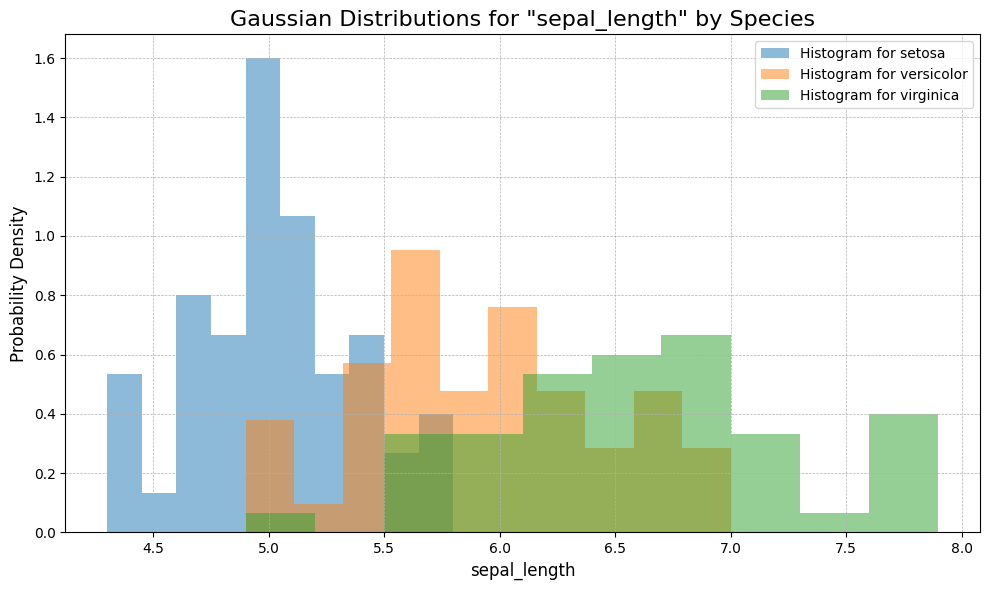

In [ ]:
plt.figure(figsize=(10, 6))

for name, data in class_data.items():
    # Plot a histogram of the actual data to show how well the Gaussian fits
    plt.hist(data, bins=10, density=True, alpha=0.5, label=f'Histogram for {name}')

plt.title(f'Gaussian Distributions for "{attribute_name}" by Species', fontsize=16)
plt.xlabel(attribute_name, fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

That is pretty cool! We can see that there are 3 histograms, and all of them (to some degree) resemble a Gaussian distribution!

### Fitting a Gaussian to the data
To generalize these findings, we fit a Gaussian distribution to them. To do this, we take the Gaussian with the mean and standard deviation of our data. Let us plot these Gaussians on top of our actual data, to see how well they match.

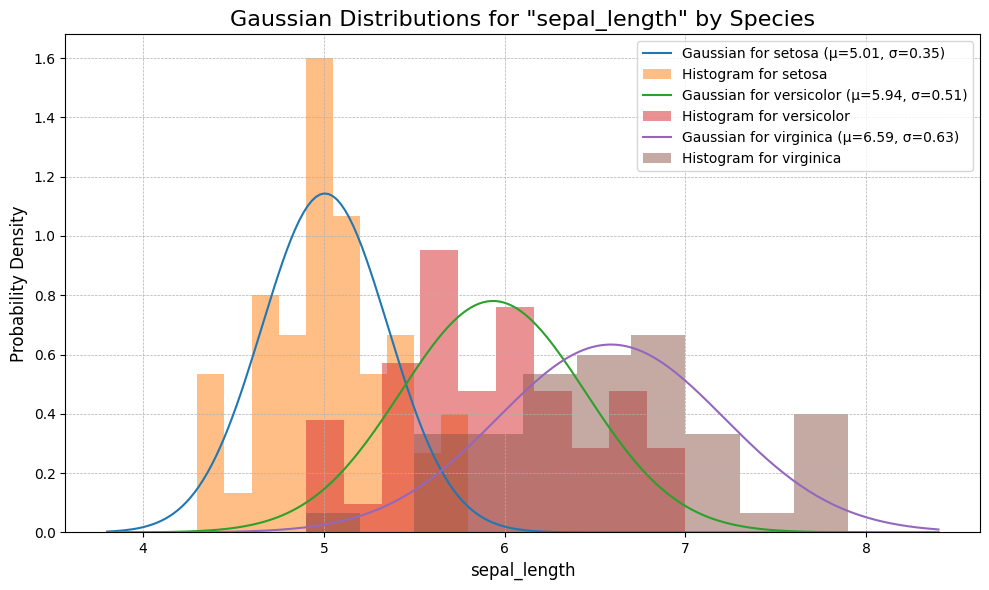

In [ ]:
plt.figure(figsize=(10, 6))
x_range = np.linspace(iris_df[attribute_name].min() - 0.5, iris_df[attribute_name].max() + 0.5, 200)
gaussian_params = {}

for name, data in class_data.items():
    # Calculate the mean (mu) and standard deviation (sigma) for the class
    mu = np.mean(data)
    sigma = np.std(data)
    gaussian_params[name] = {'mu': mu, 'sigma': sigma}
    # Generate the Gaussian (normal) distribution curve
    pdf = norm.pdf(x_range, mu, sigma)

    # Plot the Gaussian curve
    plt.plot(x_range, pdf, label=f'Gaussian for {name} (μ={mu:.2f}, σ={sigma:.2f})')

    # Plot a histogram of the actual data to show how well the Gaussian fits
    plt.hist(data, bins=10, density=True, alpha=0.5, label=f'Histogram for {name}')

plt.title(f'Gaussian Distributions for "{attribute_name}" by Species', fontsize=16)
plt.xlabel(attribute_name, fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### Classifying data points
As mentioned before, when classifying one of these datapoints, we want to pick the class which has the highest probablity to be correct. This means we want to find $P(y=A|x) > P(y=B|x)$ for a binary problem. In this case we want to find class Z such that $P(y=Z|x)$ is larger than all other classes. But then this brings us to the question, how do we compute $P(y=Z|x)$?

*Intuitively, if you look at the image above, a value such as 5 should be very clear. Why should this be setosa? But how can we mathematically show that setosa is indeed the best guess for a datapoint with sepal_lenght=5?*

#### Bayes rule
Computing $P(y=Z|x)$ directly is not easy, how do we compute the probability that y is Z given these observations? This is where Bayes rule comes in!

Bayes rule tells us that instead of checking if $P(y=A|x) > P(y=B|x)$, we can also check if
$$
\frac{P(y=A)P(x|y=A)}{P(x)} > \frac{P(y=B)P(x|y=B)}{P(x)} .
$$
Thus, when deciding on the best class label for $x$, $P(x)$ is fixed, so we may as well just check if

$$
P(y=A)P(x|y=A) > P(y=B)P(x|y=B),
$$

This means we can check if the class prior probability of class A times the class-conditional probability of that same class is larger than that same product for class B.

### Let's implement this
Below we provide an implementation for the classification of sepal_length datapoints from the iris dataset, using Bayes rule.

In [ ]:
import numpy as np
import seaborn as sns
from scipy.stats import norm

def classify_iris_sample(sample_value):
    # 1. Compute the priors and Gaussian parameters for each species
    species_data = {}
    for name in iris_df['species'].unique():
        data = iris_df[iris_df['species'] == name][attribute_name]
        species_data[name] = {
            'prior': len(data) / len(iris_df),
            'mu': np.mean(data),
            'sigma': np.std(data)
        }

    # 2. Classify the new sample based on the Bayesian decision rule
    class_probabilities = {}
    print(f"--- Classifying sample with {attribute_name}= {sample_value} ---")

    for name, params in species_data.items():
        # Calculate the class-conditional probability P(x|y) using the Gaussian PDF
        class_conditional_prob = norm.pdf(sample_value, params['mu'], params['sigma'])

        # Calculate the product of the prior and class-conditional probability P(y) * P(x|y)
        product = params['prior'] * class_conditional_prob
        class_probabilities[name] = product

        print(f"  P(y={name}) * P(x|y={name}) = {params['prior']:.2f} * {class_conditional_prob:.4f} = {product:.4f}")

    # 3. Find the most probable class
    most_probable_class = max(class_probabilities, key=class_probabilities.get)

    return most_probable_class

### Seeing it in practice
Now that we have implemented the code, all that remains is to put it to use! Let us classify a few datapoints and see if the results make sense.

In [ ]:
# Example 1: A value likely to be Setosa
sample_1 = 5
prediction_1 = classify_iris_sample(sample_1)
print(f"\nPrediction: The sample is most likely a '{prediction_1}'\n")

# Example 2: A value in the overlap region between Versicolor and Virginica
sample_2 = 6
prediction_2 = classify_iris_sample(sample_2)
print(f"\nPrediction: The sample is most likely a '{prediction_2}'\n")

# Example 3: A value likely to be Virginica
sample_3 = 6.5
prediction_3 = classify_iris_sample(sample_3)
print(f"\nPrediction: The sample is most likely a '{prediction_3}'\n")

--- Classifying sample with sepal_length= 5 ---
  P(y=setosa) * P(x|y=setosa) = 0.33 * 1.1431 = 0.3810
  P(y=versicolor) * P(x|y=versicolor) = 0.33 * 0.1458 = 0.0486
  P(y=virginica) * P(x|y=virginica) = 0.33 * 0.0263 = 0.0088

Prediction: The sample is most likely a 'setosa'

--- Classifying sample with sepal_length= 6 ---
  P(y=setosa) * P(x|y=setosa) = 0.33 * 0.0198 = 0.0066
  P(y=versicolor) * P(x|y=versicolor) = 0.33 * 0.7746 = 0.2582
  P(y=virginica) * P(x|y=virginica) = 0.33 * 0.4097 = 0.1366

Prediction: The sample is most likely a 'versicolor'

--- Classifying sample with sepal_length= 6.5 ---
  P(y=setosa) * P(x|y=setosa) = 0.33 * 0.0001 = 0.0000
  P(y=versicolor) * P(x|y=versicolor) = 0.33 * 0.4246 = 0.1415
  P(y=virginica) * P(x|y=virginica) = 0.33 * 0.6276 = 0.2092

Prediction: The sample is most likely a 'virginica'



Do you think these classifcations are sensible?